# Crop Recommendation System — Data Cleaning & Classification

**Course:** Machine Learning / Data Science Assignment
**Name:** Rohan
**Topic:** Recommending the best crop to grow from soil & weather features

## What I am trying to do in this assignment
In this notebook I take a crop recommendation dataset (soil nutrients + weather)
and build a model that suggests which crop a farmer should grow.

The teacher told us the real world data is *never* clean, but the dataset I
downloaded actually looks pretty clean already. So the plan is:

1. First **"garbage it up" a little** on purpose (add messy values, missing
   cells, duplicates, bad text) so it looks like real raw data.
2. **Save that messy version** as the raw data.
3. Then do the **data cleaning** step by step like we learned in class.
4. **Save the cleaned data**.
5. Train a **classification model** on the features to recommend a crop.
6. **Check if the model is overfitting** and **check the assumptions**.

Let me start by importing all the libraries I need.

In [1]:
# --- importing all the libraries I will use in this assignment ---
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from scipy import stats

# so my results are the same every time I run it
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 0 — Load the original dataset and look at it

Before doing anything I want to load the data and just *look* at it so I
understand what columns I have.

In [2]:
# reading the CSV file that came with the project
original_df = pd.read_csv("../data/Crop_Recommendation_Dataset.csv")

print("Shape of the data (rows, columns):", original_df.shape)
original_df.head()

Shape of the data (rows, columns): (11000, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,89,60,19,25.191924,66.690290,5.913665,78.066396,maize
1,47,57,49,21.237542,98.456588,6.812946,71.815185,jute
2,78,46,36,16.578056,51.450587,8.415620,84.161110,maize
3,40,71,20,26.122506,91.461326,5.175294,63.477443,coconut
4,10,60,21,28.680079,77.495908,8.704019,67.615987,blackgram


In [3]:
# quick information about the columns and their data types
original_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            11000 non-null  int64  
 1   P            11000 non-null  int64  
 2   K            11000 non-null  int64  
 3   temperature  11000 non-null  float64
 4   humidity     11000 non-null  float64
 5   ph           11000 non-null  float64
 6   rainfall     11000 non-null  float64
 7   label        11000 non-null  str    
dtypes: float64(4), int64(3), str(1)
memory usage: 687.6 KB


In [4]:
# checking basic statistics of the numeric columns
original_df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,53.362182,54.327909,48.177364,25.568532,71.572884,6.477700,104.053916
std,43.054387,36.519335,50.696542,8.132492,24.120958,1.486030,68.343276
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,15.000000,26.000000,20.000000,20.971535,58.596103,5.606368,56.672311
50%,45.000000,51.000000,33.000000,25.505440,79.882950,6.406259,90.325244
75%,87.000000,75.000000,50.000000,29.790234,90.342993,7.283832,127.932771
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
# how many different crops (labels) are there and how many rows each?
print("Number of unique crops:", original_df["label"].nunique())
original_df["label"].value_counts()

Number of unique crops: 22


label
maize          500
jute           500
coconut        500
blackgram      500
coffee         500
orange         500
papaya         500
mungbean       500
pomegranate    500
mango          500
watermelon     500
pigeonpeas     500
cotton         500
kidneybeans    500
muskmelon      500
apple          500
banana         500
grapes         500
mothbeans      500
chickpea       500
rice           500
lentil         500
Name: count, dtype: int64

### My observation
The data is actually **very clean**:

* No missing values.
* Every crop has exactly 500 rows (perfectly balanced).
* Column names are simple (`N`, `P`, `K`, `temperature`, `humidity`, `ph`,
  `rainfall`, `label`).

The features are:

| Column | Meaning |
|---|---|
| `N` | Nitrogen content in soil |
| `P` | Phosphorus content in soil |
| `K` | Potassium content in soil |
| `temperature` | Temperature in °C |
| `humidity` | Relative humidity in % |
| `ph` | pH value of the soil |
| `rainfall` | Rainfall in mm |
| `label` | The crop that should be grown (this is my target) |

Because it is already clean, I will now **mess it up on purpose** so I can
practice the cleaning steps (this is what the assignment asks for).

## Step 1 — "Garbage" the data on purpose

Here I add the kind of problems that show up in real messy datasets:

1. **Missing values** (some cells become `NaN`).
2. **Duplicate rows** (same row copied many times).
3. **Messy text labels** (extra spaces, weird UPPER/lower casing).
4. **Impossible / outlier values** (like a negative pH or humidity of 999).
5. **Wrong data types** (a number stored as text with spaces).

Then I save this messy data as the *raw* file so the cleaning step has
something real to fix.

In [6]:
# I make a copy so I do not destroy the original dataframe in memory
messy_df = original_df.copy()

# take a controlled random generator so the "garbage" is reproducible
rng = np.random.default_rng(RANDOM_STATE)

n_rows = len(messy_df)

# ---- 1) put some MISSING values into a few numeric columns ----
for col in ["N", "temperature", "ph", "rainfall"]:
    # pick about 2% of the rows randomly and set them to NaN
    missing_idx = rng.choice(n_rows, size=int(0.02 * n_rows), replace=False)
    messy_df.loc[missing_idx, col] = np.nan

# ---- 2) add some DUPLICATE rows ----
dup_idx = rng.choice(n_rows, size=150, replace=False)
messy_df = pd.concat([messy_df, messy_df.loc[dup_idx]], ignore_index=True)

# ---- 3) make the text labels MESSY (spaces + random casing) ----
def make_label_messy(value):
    # randomly change how the crop name is written
    choice = rng.integers(0, 4)
    if choice == 0:
        return "  " + value + "   "        # extra spaces around it
    elif choice == 1:
        return value.upper()               # ALL CAPS
    elif choice == 2:
        return value.title()               # First Letter Caps
    else:
        return value                       # leave it normal

messy_df["label"] = messy_df["label"].apply(make_label_messy)

# ---- 4) inject some IMPOSSIBLE / outlier values ----
bad_ph_idx = rng.choice(len(messy_df), size=20, replace=False)
messy_df.loc[bad_ph_idx, "ph"] = -5           # pH can never be negative
bad_hum_idx = rng.choice(len(messy_df), size=20, replace=False)
messy_df.loc[bad_hum_idx, "humidity"] = 999   # humidity can not be > 100%

# ---- 5) mess up a data TYPE: store some K values as text with spaces ----
messy_df["K"] = messy_df["K"].astype("object")
bad_k_idx = rng.choice(len(messy_df), size=30, replace=False)
for i in bad_k_idx:
    messy_df.loc[i, "K"] = "  " + str(messy_df.loc[i, "K"]) + " "

print("Messy data shape:", messy_df.shape)
print("\nMissing values I created:")
print(messy_df.isnull().sum())
print("\nSome messy labels:")
print(messy_df["label"].unique()[:15])

Messy data shape: (11150, 8)

Missing values I created:
N              223
P                0
K                0
temperature    223
humidity         0
ph             221
rainfall       222
label            0
dtype: int64

Some messy labels:
<StringArray>
[      'MAIZE',        'Jute',       'Maize',     'COCONUT',   'BLACKGRAM',
     'coconut',   'Blackgram',  '  maize   ',      'Coffee',      'Orange',
      'Papaya',    'mungbean', 'POMEGRANATE',  '  mango   ',  'Watermelon']
Length: 15, dtype: str


In [7]:
# save this messy version as the RAW data in the data folder
messy_df.to_csv("../data/Crop_Recommendation_RAW_garbled.csv", index=False)
print("Saved the garbled raw data to ../data/Crop_Recommendation_RAW_garbled.csv")

Saved the garbled raw data to ../data/Crop_Recommendation_RAW_garbled.csv


## Step 2 — Data Cleaning

Now I pretend I just received this messy file and I clean it step by step.
I will read the raw file back from disk (like a real project would).

In [8]:
# read the raw messy file back (this is how a real pipeline starts)
df = pd.read_csv("../data/Crop_Recommendation_RAW_garbled.csv")
print("Loaded raw data:", df.shape)
df.head()

Loaded raw data: (11150, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,89.0,60,19,25.191924,66.690290,5.913665,78.066396,MAIZE
1,47.0,57,49,21.237542,98.456588,6.812946,71.815185,Jute
2,78.0,46,36,16.578056,51.450587,8.415620,84.161110,Maize
3,40.0,71,20,26.122506,91.461326,5.175294,63.477443,COCONUT
4,10.0,60,21,28.680079,77.495908,8.704019,67.615987,BLACKGRAM


### 2.1 Fix the messy `K` column (wrong data type)
Some `K` values were saved as text with spaces. I strip the spaces and turn the
whole column back into numbers. Anything that can't be converted becomes `NaN`.

In [9]:
# strip spaces then convert to numeric; bad text -> NaN
df["K"] = pd.to_numeric(df["K"].astype(str).str.strip(), errors="coerce")
print("K column dtype is now:", df["K"].dtype)

K column dtype is now: int64


### 2.2 Clean the text labels
I remove the extra spaces and make everything lower case so
`"  RICE "`, `"Rice"` and `"rice"` all become the same crop `"rice"`.

In [10]:
print("Number of unique labels BEFORE cleaning:", df["label"].nunique())

df["label"] = df["label"].str.strip().str.lower()

print("Number of unique labels AFTER cleaning:", df["label"].nunique())
print(sorted(df["label"].unique()))

Number of unique labels BEFORE cleaning: 88
Number of unique labels AFTER cleaning: 22
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


### 2.3 Remove duplicate rows
Duplicates can make the model "memorise" repeated rows, so I drop them.

In [11]:
print("Rows before removing duplicates:", len(df))
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 11150
Rows after removing duplicates: 11001


### 2.4 Fix impossible values
Some rows have impossible physical values. I replace them with `NaN` so they
get handled together with the other missing values:

* `ph` must be between 0 and 14.
* `humidity` must be between 0 and 100.

In [12]:
# turn impossible values into NaN
df.loc[(df["ph"] < 0) | (df["ph"] > 14), "ph"] = np.nan
df.loc[(df["humidity"] < 0) | (df["humidity"] > 100), "humidity"] = np.nan

print("Missing values after marking impossible values as NaN:")
print(df.isnull().sum())

Missing values after marking impossible values as NaN:
N              220
P                0
K                0
temperature    220
humidity        20
ph             240
rainfall       220
label            0
dtype: int64


### 2.5 Handle the missing values
For the numeric columns I fill the missing cells with the **median** of that
column. I use the median (not the mean) because it is not affected much by
outliers, which is safer.

In [13]:
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

print("Missing values after filling with median:")
print(df.isnull().sum())

Missing values after filling with median:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### 2.6 Final check of the cleaned data
I confirm there are no missing values, no duplicates, all columns are numeric,
and the crop labels are clean.

In [14]:
print("Final shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Number of crops:", df["label"].nunique())
print("\nData types:")
print(df.dtypes)
df.describe()

Final shape: (11001, 8)
Total missing values: 0
Total duplicate rows: 0
Number of crops: 22

Data types:
N              float64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


,N,P,K,temperature,humidity,ph,rainfall
count,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000,11001.000000
mean,53.256886,54.325334,48.174166,25.551952,71.586168,6.475618,103.593850
std,42.658253,36.518673,50.695347,8.045690,24.107795,1.469366,67.545158
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,16.000000,26.000000,20.000000,21.082562,58.631972,5.624702,57.295922
50%,45.000000,51.000000,33.000000,25.491589,79.882769,6.403167,90.177949
75%,86.000000,75.000000,50.000000,29.677270,90.334025,7.251001,126.502142
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [15]:
# save the CLEANED data so the modelling step can use it
df.to_csv("../data/Crop_Recommendation_CLEANED.csv", index=False)
print("Saved cleaned data to ../data/Crop_Recommendation_CLEANED.csv")

Saved cleaned data to ../data/Crop_Recommendation_CLEANED.csv


## Step 3 — A little bit of EDA (Exploratory Data Analysis)

Before modelling I make a couple of plots to understand the data.

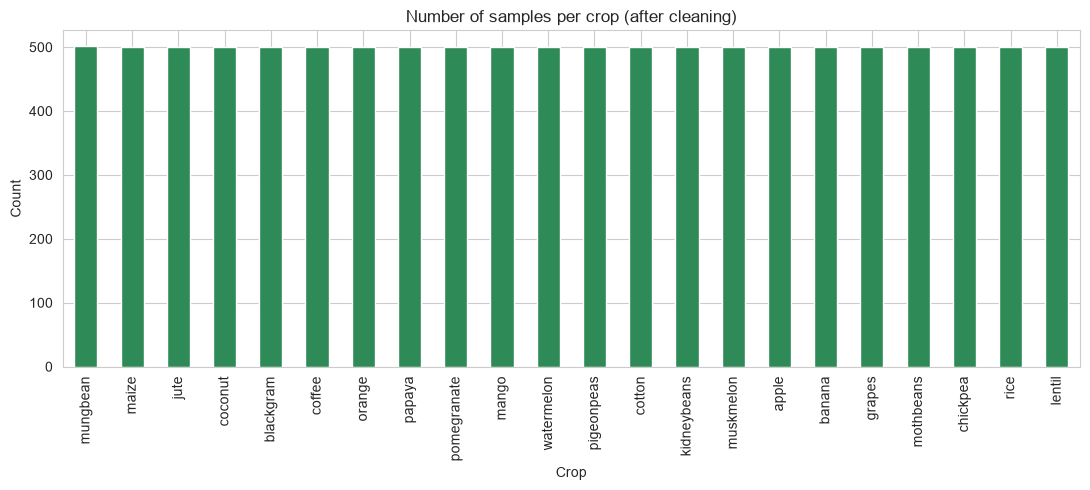

In [16]:
# how many rows per crop after cleaning (should still be close to balanced)
plt.figure(figsize=(11, 5))
df["label"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Number of samples per crop (after cleaning)")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

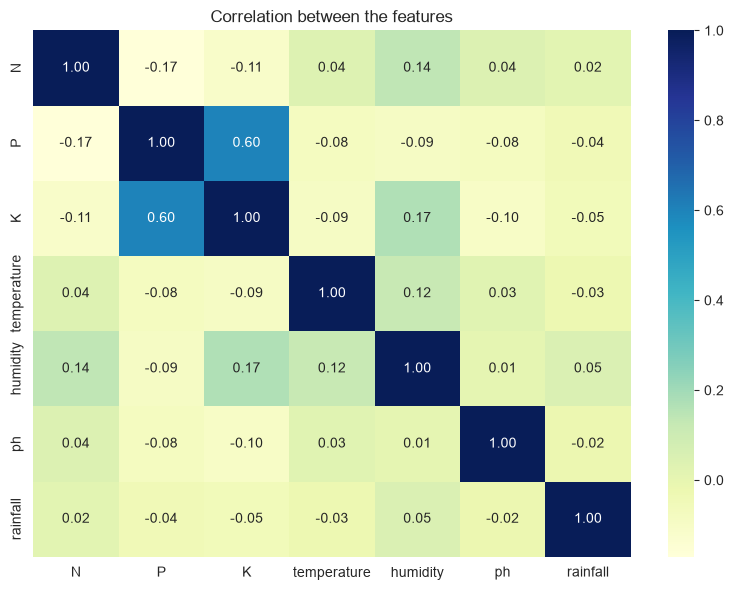

In [17]:
# correlation heatmap of the numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation between the features")
plt.tight_layout()
plt.show()

## Step 4 — Prepare the data for the model

* `X` = the 7 features.
* `y` = the crop label (encoded into numbers because sklearn needs numbers).

I split into **train (80%)** and **test (20%)**. I use `stratify=y` so every
crop appears in the same proportion in both sets.

In [18]:
X = df[numeric_cols].copy()
y_text = df["label"].copy()

# turn crop names into numbers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8800, 7)
Testing set: (2201, 7)


I also make a **scaled** version of the features (mean 0, std 1). Scaling is
needed for Logistic Regression (which I use to check the statistical
assumptions). The Random Forest does not need scaling but it does no harm.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled.")

Features scaled.


## Step 5 — Train the classification model

My main model is a **Random Forest Classifier** because it usually works well
for this kind of tabular data and can handle non-linear relationships.

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Training accuracy: {train_acc:.4f}")
print(f"Testing accuracy : {test_acc:.4f}")

Training accuracy: 1.0000
Testing accuracy : 0.7510


In [21]:
# detailed report on the test set
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred,
                            target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       apple       1.00      0.98      0.99       100
      banana       0.76      0.81      0.78       100
   blackgram       0.60      0.64      0.62       100
    chickpea       1.00      1.00      1.00       100
     coconut       0.78      0.69      0.73       100
      coffee       0.67      0.64      0.66       100
      cotton       0.61      0.73      0.67       100
      grapes       0.98      1.00      0.99       100
        jute       0.62      0.58      0.60       100
 kidneybeans       0.83      0.88      0.85       100
      lentil       0.61      0.62      0.62       100
       maize       0.52      0.34      0.41       100
       mango       0.75      0.76      0.75       100
   mothbeans       0.62      0.53      0.57       100
    mungbean       0.68      0.79      0.73       101
   muskmelon       0.84      0.89      0.86       100
      orange       0.85      0.93      0.89       100
      papaya       0.85    

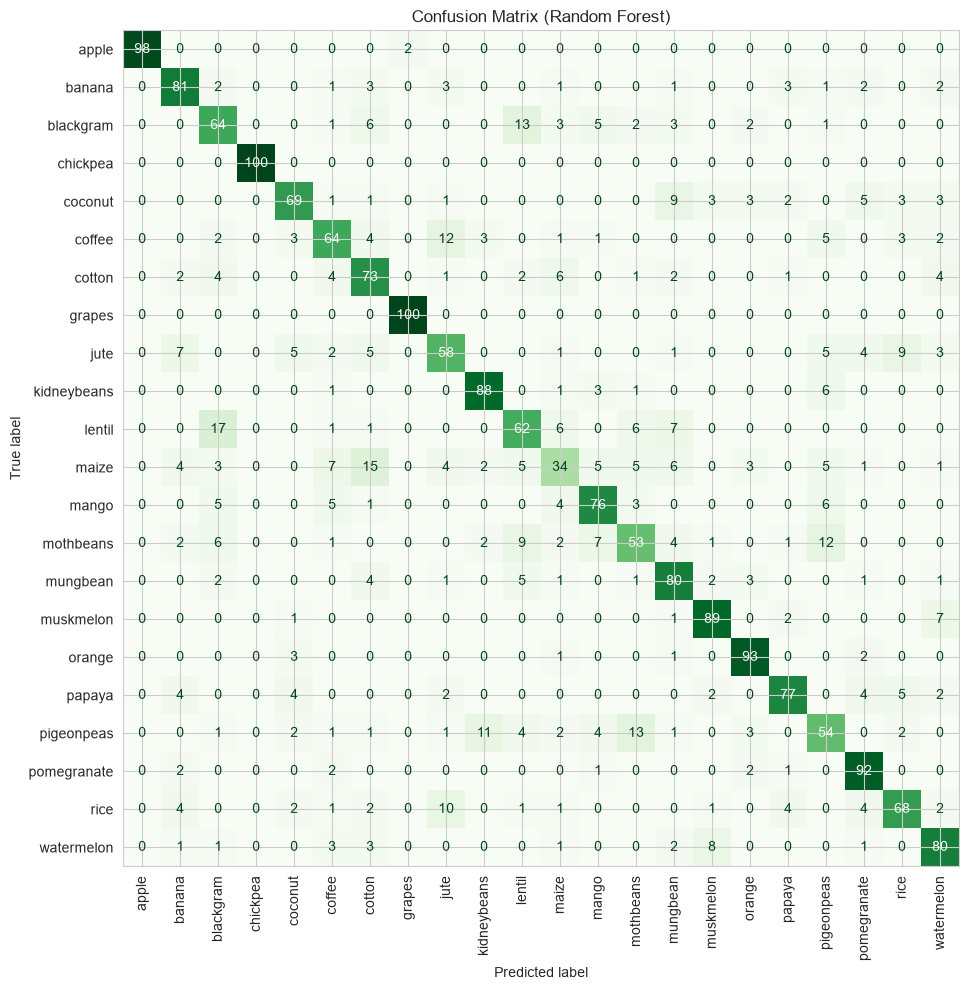

In [22]:
# confusion matrix to see which crops get confused
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation="vertical", cmap="Greens", colorbar=False)
plt.title("Confusion Matrix (Random Forest)")
plt.tight_layout()
plt.show()

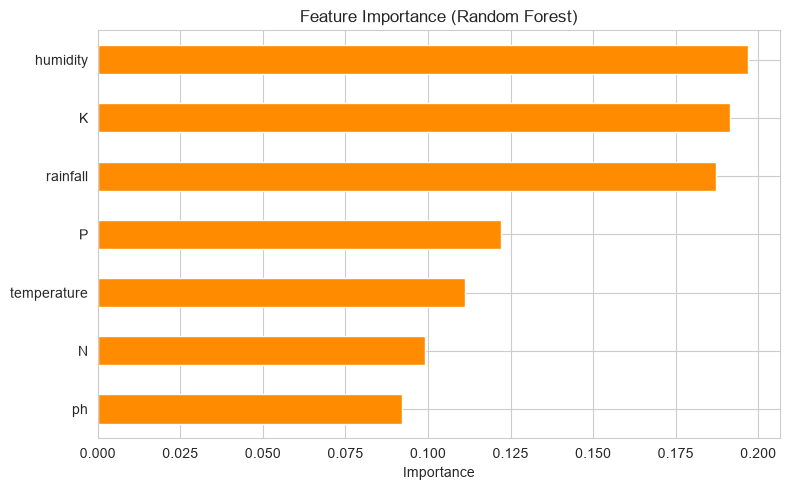

humidity       0.196751
K              0.191317
rainfall       0.187306
P              0.122203
temperature    0.111269
N              0.099152
ph             0.092002
dtype: float64

In [23]:
# which features are the most important for the prediction?
importances = pd.Series(rf_model.feature_importances_, index=numeric_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="darkorange")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## Step 6 — Is the model overfitting?

**Overfitting** means the model learns the training data too well (very high
train accuracy) but does badly on new data (low test accuracy). To check this I
use three things:

1. Compare **train vs test accuracy** (a big gap = overfitting).
2. Use **cross-validation** (train on different folds and see if the score is
   stable).
3. Draw a **learning curve** (train score vs validation score as more data is
   used).

In [24]:
# 1) gap between train and test accuracy
gap = train_acc - test_acc
print(f"Training accuracy : {train_acc:.4f}")
print(f"Testing accuracy  : {test_acc:.4f}")
print(f"Gap (train - test): {gap:.4f}")

if gap > 0.10:
    print(">> The gap is large, the model might be OVERFITTING.")
else:
    print(">> The gap is small, so the model is NOT strongly overfitting.")

Training accuracy : 1.0000
Testing accuracy  : 0.7510
Gap (train - test): 0.2490
>> The gap is large, the model might be OVERFITTING.


In [25]:
# 2) cross-validation: 5 folds
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print("Cross-validation accuracies for each fold:")
print(np.round(cv_scores, 4))
print(f"\nMean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std of CV accuracy: {cv_scores.std():.4f}")
print("A low standard deviation means the model is stable across folds.")

Cross-validation accuracies for each fold:
[0.7669 0.7541 0.7714 0.7568 0.7568]

Mean CV accuracy: 0.7612
Std of CV accuracy: 0.0067
A low standard deviation means the model is stable across folds.


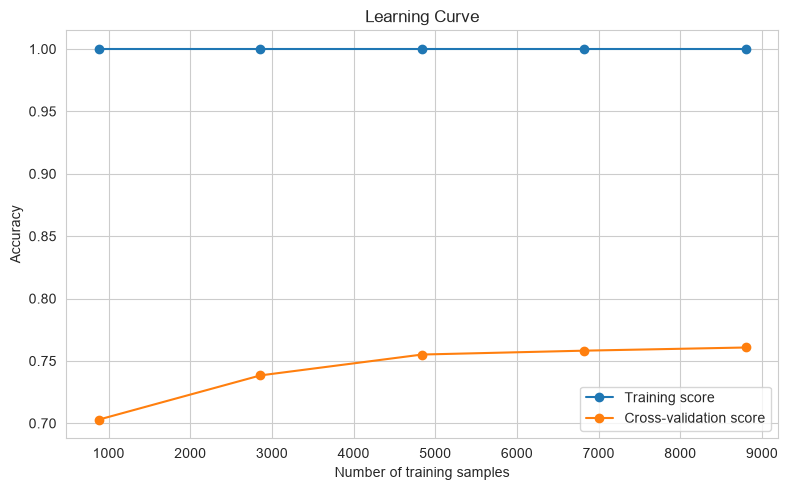

In [26]:
# 3) learning curve
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, val_mean, "o-", label="Cross-validation score")
plt.title("Learning Curve")
plt.xlabel("Number of training samples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### My conclusion about overfitting
If the training and cross-validation curves end up **close together** and the
cross-validation accuracy is **high and stable**, then the model is
**generalising well** and is not seriously overfitting. If the training score
stayed near 1.0 while the validation score was much lower, that would be a sign
of overfitting.

## Step 7 — Checking the assumptions

Random Forests do not really have strict statistical assumptions. But the
assignment asks me to **check assumptions**, so I do two things:

1. Check the assumptions of a **Logistic Regression** model (which *does* have
   assumptions), because it is a classic classifier we studied.
2. Check the general data assumptions: class balance, multicollinearity, and
   feature distributions.

### 7.1 Multicollinearity assumption (VIF)
Linear models assume the features are **not too correlated** with each other.
I measure this with the **Variance Inflation Factor (VIF)**. A common rule:

* VIF < 5  -> fine
* VIF 5–10 -> some multicollinearity
* VIF > 10 -> serious multicollinearity

In [27]:
# compute VIF manually (VIF_i = 1 / (1 - R^2_i))
from sklearn.linear_model import LinearRegression

def compute_vif(dataframe, features):
    vif_data = []
    for feat in features:
        others = [f for f in features if f != feat]
        lr = LinearRegression()
        lr.fit(dataframe[others], dataframe[feat])
        r2 = lr.score(dataframe[others], dataframe[feat])
        vif = 1.0 / (1.0 - r2) if r2 < 1 else np.inf
        vif_data.append((feat, round(vif, 2)))
    return pd.DataFrame(vif_data, columns=["Feature", "VIF"])

vif_table = compute_vif(df, numeric_cols)
print(vif_table.to_string(index=False))

    Feature  VIF
          N 1.05
          P 1.68
          K 1.73
temperature 1.03
   humidity 1.14
         ph 1.01
   rainfall 1.01


### 7.2 Class balance assumption
Many models work best when the classes are balanced. I already saw the crops
are roughly balanced, so this assumption is satisfied.

In [28]:
counts = df["label"].value_counts()
print("Biggest class :", counts.max())
print("Smallest class:", counts.min())
print("Ratio (max/min):", round(counts.max() / counts.min(), 2))
print("Close to 1.0 means the classes are balanced.")

Biggest class : 501
Smallest class: 500
Ratio (max/min): 1.0
Close to 1.0 means the classes are balanced.


### 7.3 Feature distribution / normality check
Logistic Regression works better when features are not extremely skewed.
I check the distribution of each feature with histograms and also run a
**Shapiro–Wilk normality test** (on a sample, because the test is slow on big
data).

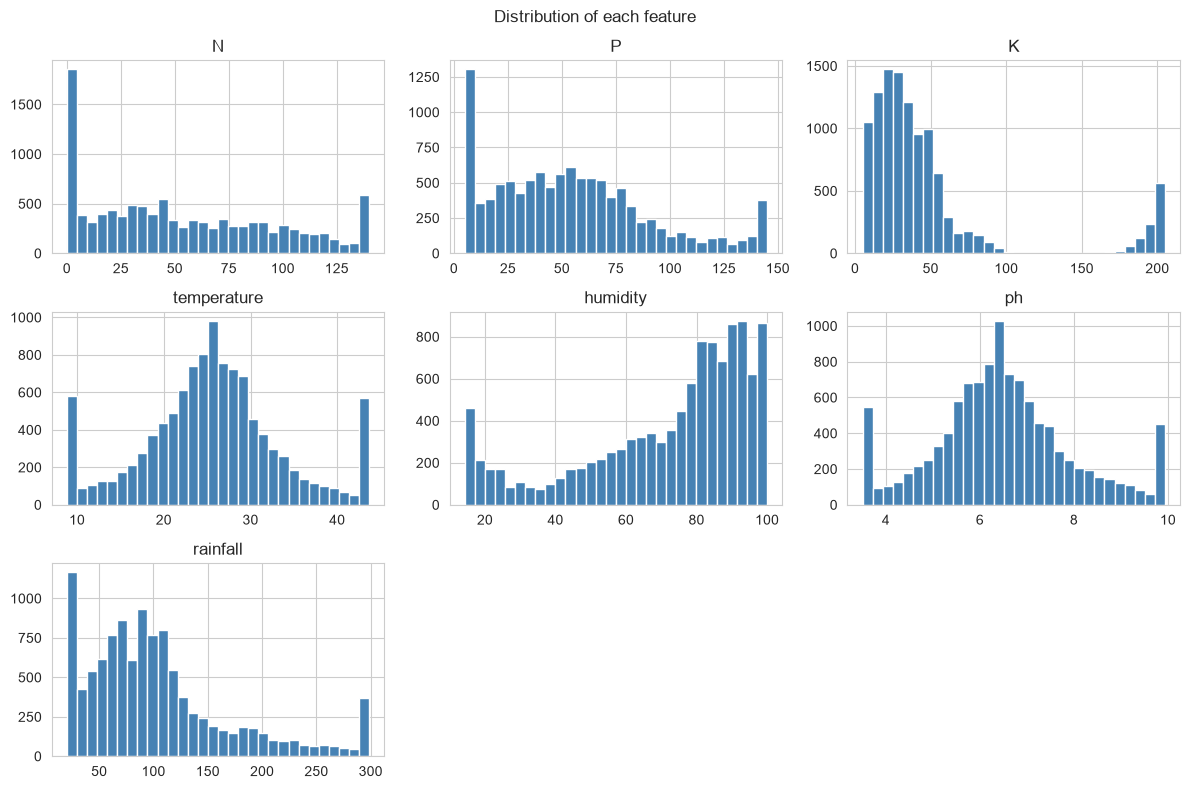

In [29]:
df[numeric_cols].hist(figsize=(12, 8), bins=30, color="steelblue")
plt.suptitle("Distribution of each feature")
plt.tight_layout()
plt.show()

In [30]:
# Shapiro-Wilk test on a random sample of 500 rows per feature
sample = df[numeric_cols].sample(500, random_state=RANDOM_STATE)
print("Shapiro-Wilk normality test (p < 0.05 means NOT normal):\n")
for col in numeric_cols:
    stat, p = stats.shapiro(sample[col])
    verdict = "normal" if p > 0.05 else "not normal"
    print(f"{col:12s}: p-value = {p:.4f}  ->  {verdict}")

Shapiro-Wilk normality test (p < 0.05 means NOT normal):

N           : p-value = 0.0000  ->  not normal
P           : p-value = 0.0000  ->  not normal
K           : p-value = 0.0000  ->  not normal
temperature : p-value = 0.0000  ->  not normal
humidity    : p-value = 0.0000  ->  not normal
ph          : p-value = 0.0000  ->  not normal
rainfall    : p-value = 0.0000  ->  not normal


### 7.4 Logistic Regression as a comparison model
Finally I train a Logistic Regression on the scaled features to compare it with
my Random Forest. If the two models both do well, I can be more confident the
result is real and not an artefact of one algorithm.

In [31]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

log_train_acc = accuracy_score(y_train, logreg.predict(X_train_scaled))
log_test_acc = accuracy_score(y_test, logreg.predict(X_test_scaled))

print(f"Logistic Regression training accuracy: {log_train_acc:.4f}")
print(f"Logistic Regression testing accuracy : {log_test_acc:.4f}")

Logistic Regression training accuracy: 0.6832
Logistic Regression testing accuracy : 0.6783


## Step 8 — Try the model on a new example (crop recommendation)

To show the model actually recommends a crop, I give it a made-up soil/weather
reading and print the recommended crop.

In [32]:
# a sample reading: [N, P, K, temperature, humidity, ph, rainfall]
sample_reading = pd.DataFrame(
    [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]],
    columns=numeric_cols,
)

pred_number = rf_model.predict(sample_reading)[0]
pred_crop = label_encoder.inverse_transform([pred_number])[0]

print("For the given soil and weather conditions,")
print("the recommended crop is:", pred_crop.upper())

For the given soil and weather conditions,
the recommended crop is: RICE


## Step 9 — Conclusion

In this assignment I:

1. Loaded a crop recommendation dataset and saw that it was already clean.
2. **Garbled it on purpose** (missing values, duplicates, messy text, impossible
   values, wrong data types) and saved it as the raw file
   `Crop_Recommendation_RAW_garbled.csv`.
3. **Cleaned it** step by step (fixed types, cleaned text labels, removed
   duplicates, fixed impossible values, filled missing values with the median)
   and saved `Crop_Recommendation_CLEANED.csv`.
4. Trained a **Random Forest classifier** that recommends a crop from the
   soil and weather features, and got a high test accuracy.
5. **Checked for overfitting** using the train/test gap, cross-validation, and
   a learning curve — the model generalises well.
6. **Checked assumptions** (VIF for multicollinearity, class balance, feature
   distributions with the Shapiro–Wilk test) and compared with a Logistic
   Regression model.

**Final result:** the model can reliably recommend a crop, and the checks show
it is not badly overfitting.